# 基于朗之万动力学的得分匹配模型 (SMLD)

基于得分的生成模型（`Score-based Generative Models`） 是从目标分布中生成数据的另一种方法。

在本教程中，我们将介绍一种较早的基于得分的生成模型方法 —— **基于朗之万动力学的得分匹配模型**（Score Matching with Langevin Dynamics, SMLD）。
该方法在训练阶段通过向数据添加噪声来估计并学习得分函数（即对数概率密度函数关于数据的梯度）。在生成（推理）阶段，模型利用朗之万动力学，通过逐步降低噪声、并进行足够多步的迭代，从而从该分布中采样生成数据。


> 说明： SMLD 是在 DDPM 之前提出的工作（实验证明，DDPM 在样本质量上优于 SMLD）。
> 为了给下一章节（基于随机微分方程的得分建模）做铺垫，在介绍完 DDPM 之后，本笔记本将进一步讨论基于得分的生成模型方法。

---

## 架构与方法

下面我们将参考其原始论文[[Song & Ermon, 2019]](https://arxiv.org/pdf/1907.05600)，简要回顾**基于朗之万动力学的得分匹配**（Score Matching with Langevin Dynamics, SMLD）的理论基础。

首先介绍用于从真实分布 $p(\mathbf{x})$ 中进行采样的**朗之万方程（Langevin Equation）**。  
通过对下式进行迭代计算 $t=1, \ldots , T$，即可逐步生成样本。

$$\displaystyle \mathbf{x}_t = \mathbf{x}_{t-1} + \tau \nabla_{\mathbf{x}_{t-1}} \log p(\mathbf{x}) + \sqrt{2 \tau}\mathbf{z} \;\;\;\;\;\; (1)$$

其中

* $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
* $\tau$ 是步长的参数。
* $\mathbf{x}_0$ 是随机选取的。

这个方程源自物理学，描述了布朗运动。

从数学角度来看，这个方程可以直观地理解为“梯度上升 + 随机噪声”的组合。其中，项 $\mathbf{x}_{t-1} + \tau \nabla_{\mathbf{x}_{t-1}} \log p(\mathbf{x})$ 对应于对数似然函数的梯度上升过程，而项 $\sqrt{2 \tau}\mathbf{z}$ 则表示随机扰动（随机游走噪声）。

当样本点距离概率分布的峰值较远时，梯度项会产生较强的拉动作用，将其迅速推向高概率区域；当样本点接近峰值时，梯度项的作用减弱，样本主要在峰值附近进行小幅随机波动（左右摆动）。

正如下图实验结果所示，当迭代步数 $t$ 足够大时，利用朗之万方程可以逐渐采样出服从真实分布 $p(\mathbf{x})$ 的数据样本。（即：迭代步数越大，噪声影响越小，生成的样本分布越接近真实分布。）

![Applying Langevin experiments](./assets/langevin_experiments.png)

就图像生成而言，如果我们知道真实图像像素 $\mathbf{x}$ 的分布，那么我们就可以通过应用朗之万动力学来生成图像样本。
现在我们关心的是如何获得用于图像生成的 $\nabla_{\mathbf{x}} \log p(\mathbf{x})$（在朗之万方程中）。

为了实现这一点，首先让我们定义以下函数 $\mathbf{s}_{\theta}(\mathbf{x})$，称为 **(Stein's) 得分**。（在这个例子中，我假设函数 $\mathbf{s}_{\theta}(\mathbf{x})$ 是由神经网络实现的。）

$$\displaystyle \mathbf{s}_{\theta}(\mathbf{x}) \stackrel{\mathrm{def}}{=} \nabla_{\mathbf{x}} \log p(\mathbf{x})$$

其中 $\theta$ 是函数 $\mathbf{s}(\cdot)$ 的一组参数。

> 注：请不要与用于最大对数似然估计 (MLE) 的普通得分函数混淆，后者定义为：$\mathbf{s}_{\mathbf{x}}(\theta) \stackrel{\mathrm{def}}{=} \nabla_{\theta} \log p_{\theta}(\mathbf{x}) $

现在我们想要估计以下方程 $J(\theta)$，以便计算 $\mathbf{s}_{\theta}(\mathbf{x})$ 和 $\nabla_{\mathbf{x}} \log p(\mathbf{x})$ 之间的损失。
但是这个问题的难点在于如何获得 $\nabla_{\mathbf{x}} \log p(\mathbf{x})$，因为 $p(\mathbf{x})$ 是一个未知分布。（这就是名称暗示“得分匹配”问题的原因。）

$$\displaystyle J(\theta) = \frac{1}{2} \mathbb{E}_{p(\mathbf{x})} \left[ \| \mathbf{s}_{\theta}(\mathbf{x}) - \nabla_{\mathbf{x}} \log p(\mathbf{x}) \|^2 \right]$$

可能有几种方法可以解决这个问题。
例如，您可以采用非参数方法来近似 $p(\mathbf{x})$，例如应用 [这里](https://tsmatz.wordpress.com/2020/06/01/svm-and-kernel-functions-mathematics/) 讨论的核密度估计（这种方法称为**显式得分匹配** (Explicit Score Matching)），但这种方法可能可扩展性较差，因为当数据量大时会导致复杂的计算。
另一种方法是 [[A Hyvärinen, 2005](https://jmlr.org/papers/volume6/hyvarinen05a/hyvarinen05a.pdf)] 中讨论的一种估计技术（针对未归一化模型），但当得分函数由神经网络实现时，这种方法也可能难以计算。

为了克服这个问题，我们在这里应用**去噪得分匹配 (Denoising Score Matching, DSM)** 技术 [[Vincent, 2010](https://www.iro.umontreal.ca/~vincentp/Publications/smdae_techreport.pdf)]，如下所示。

首先，我们定义图像 $\mathbf{x}$ 的预定义噪声分布 $q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x})$，其中 $\sigma$ 是一组噪声分布中的参数。然后可以使用观测数据点 $\mathbf{x}$ 定义边际扰动数据分布 $q_{\sigma}(\tilde{\mathbf{x}})$ 如下：

$$\displaystyle q_{\sigma}(\tilde{\mathbf{x}}) \stackrel{\mathrm{def}}{=} \int q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x}) p(\mathbf{x}) d\mathbf{x}$$

在此假设下，我们尝试使用得分匹配（即计算 $J(\theta)$）来估计此扰动数据分布的得分，并且已知（已证明）目标等同于最小化以下方程。（见下面的注释。）

$$\displaystyle J_{DSM}(\theta) = \frac{1}{2} \mathbb{E}_{q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x}) p(\mathbf{x})} \left[ \| \mathbf{s}_{\theta}(\tilde{\mathbf{x}}) - \nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x}) \|^2 \right] \;\;\;\;\;\; (2)$$

其中 $\mathbb{E}_{q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x}) p(\mathbf{x})}[\cdot]$ 表示在 $\mathbf{x} \sim p(\mathbf{x})$ 和 $\tilde{\mathbf{x}} \sim q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x})$ 下的期望。

> 注：有关证明，请参阅 [[Vincent, 2010](https://www.iro.umontreal.ca/~vincentp/Publications/smdae_techreport.pdf)] 中的附录。
> 当我们将核密度估计（即显式得分匹配）的损失表示为 $J_{ESM}(\theta)$（$\approx J(\theta)$）时，已知（已证明）：
> $$J_{DSM}(\theta) = J_{ESM}(\theta) + C$$
> 其中 $C$ 是一个不依赖于 $\theta$ 的常数。

现在，让我们假设 $q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x})=\mathcal{N}(\tilde{\mathbf{x}}|\mathbf{x},\sigma^2)$。
在此假设下，$\nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x})$ 可以转化为：

$\displaystyle \nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x})$

$\displaystyle =\nabla_{\tilde{\mathbf{x}}} \log \frac{1}{(\sqrt{2\pi\sigma^2})^d} \exp \left\{ -\frac{\| \tilde{\mathbf{x}}-\mathbf{x} \|^2}{2\sigma^2} \right\}$

$\displaystyle =-\frac{\tilde{\mathbf{x}} - \mathbf{x}}{\sigma^2}$

其中 $d$ 是维度数。

现在我们可以令 $\tilde{\mathbf{x}} = \mathbf{x} + \sigma \mathbf{z}$，其中 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$。
通过在方程 (2) 中代入 $\tilde{\mathbf{x}}$ 和 $\nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}}|\mathbf{x})$，目标 $J_{DSM}(\theta)$ 可以简化如下。

$$\displaystyle J_{DSM}(\theta) = \mathbb{E}_{p(\mathbf{x})} \left[ \frac{1}{2} \left\| \mathbf{s}_{\theta}(\mathbf{x} + \sigma \mathbf{z}) + \frac{\mathbf{z}}{\sigma} \right\|^2 \right]$$

该公式表明，当输入中加入噪声 $\mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$ 时，$\mathbf{s}_{\theta}(\cdot)$（即对 $\nabla_{\mathbf{x}} \log p(\mathbf{x})$ 的近似）实际上在预测噪声项 $-\mathbf{z} / \sigma$。  
这正是该方法被称为“去噪（denoising）”得分匹配的原因。

为了在多种不同的 $\sigma$（方差）条件下实现泛化，原始论文提出通过最小化如下目标函数来进行训练（详见原文 [[Song & Ermon, 2019](https://arxiv.org/pdf/1907.05600)]）：

- 选取一组噪声水平 $\{\sigma_i\}_{i=1}^L$，其中噪声序列满足  
  $\sigma_1/\sigma_2 = \ldots = \sigma_{L-1} / \sigma_L > 1$；
- 不再使用单一的 $\mathbf{s}_{\theta}(\mathbf{x})$，而是采用条件得分网络 $\mathbf{s}_{\theta}(\mathbf{x}, \sigma_i)$，其输出依赖于所施加的噪声水平 $\sigma_i$。该网络称为 **Noise Conditional Score Network (NCSN)**。  
  在本示例中，我们将构建 $\mathbf{s}_{\theta}(\mathbf{x}, i)$，并对索引 $i$ 进行时间步嵌入（具体实现见后文）；
- 随后，通过最小化下述损失函数来优化 NCSN 的参数 $\theta$。

$$\displaystyle \frac{1}{L} \sum_{i=1}^L \sigma_i^2 \mathbb{E}_{p(\mathbf{x})} \left[ \frac{1}{2} \left\| \mathbf{s}_{\theta}(\mathbf{x} + \sigma_i \mathbf{z}, i) + \frac{\mathbf{z}}{\sigma_i} \right\|^2 \right] $$

在批次大小为 $M$ 的实际训练中，我们将优化 $\theta$ 以最小化以下损失。

$$\displaystyle \frac{1}{M} \sum_{n=1}^M \sigma_{i_n}^2 \mathbb{E}_{p(\mathbf{x})} \left[ \frac{1}{2} \left\| \mathbf{s}_{\theta}(\mathbf{x} + \sigma_{i_n} \mathbf{z}, {i_n}) + \frac{\mathbf{z}}{\sigma_{i_n}} \right\|^2 \right] $$

其中 $i_n \in \{1,\ldots,L\}$。

对于使用 NCSN 进行推断（图像生成），我们首先初始化 $\mathbf{x}_0$，然后对 $t=1, \ldots ,T$ 和 $i=1, \ldots ,L$（即嵌套循环）应用以下方程。

$$\displaystyle \mathbf{x}_t = \mathbf{x}_{t-1} + \frac{\alpha_i}{2} \mathbf{s}_{\theta}(\mathbf{x}_{t-1}, i) + \sqrt{\alpha_i}\mathbf{z}_t $$

其中 $\alpha_i = \epsilon \cdot \sigma_i^2 / \sigma_L^2$（带有缩放参数 $\epsilon$ 的步长）并且 $\mathbf{z}_t \sim \mathcal{N}(\mathbf{0},\mathbf{I})$。

---

## 构建和训练模型

现在让我们一步一步地查看代码（实现）并描述其理论方面。

> 注：官方实现请参阅 [这里](https://github.com/ermongroup/ncsn)。

在我们开始之前，我们需要安装所需的包。

In [5]:
!pip install torch torchvision numpy matplotlib tqdm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


### 1. 加载数据

我们加载图像 (CIFAR-10) 数据集和数据加载器。
每个批次的形状为 ```[batch_size, 3, 32 32]```。

In [7]:
import torch
from torchvision import datasets, transforms

batch_size = 128

dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


现在我展示 100 个示例。

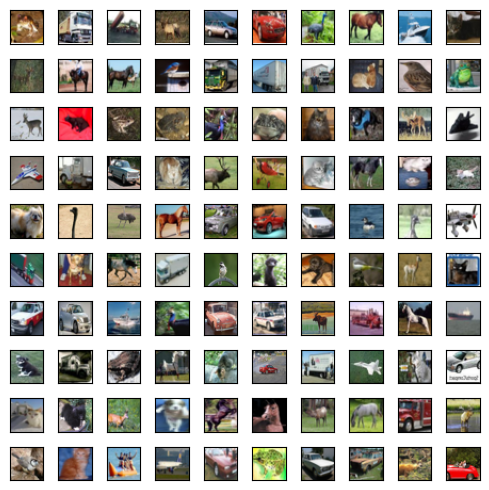

In [9]:
import numpy as np
import matplotlib.pyplot as plt

"""
for _, (data, _) in enumerate(loader):
    images = data[:3]
    break
for i in images:
    channel_last = np.transpose(i.numpy(), (1, 2, 0)) # (C, H, W) --> (H, W, C)
    plt.figure(figsize = (0.4,0.4))
    plt.imshow(channel_last)
    plt.show()
"""
num_row = 10
num_col = 10
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
tmp_loader = torch.utils.data.DataLoader(dataset, batch_size=num_row*num_col, shuffle=False)
for data, _ in tmp_loader:
    for i in range(num_row*num_col):
        image = data[i].numpy()
        channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
        row = i//num_col
        col = i%num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(channel_last)
    break
plt.tight_layout()
plt.show()
del tmp_loader

### 2. 初始化 $\{\sigma_i\}_{i=1}^L$

现在我们初始化 $\{\sigma_i\}_{i=1}^L$。

为了使 $\sigma_{i-1} / \sigma_i$ 成为一个常数 ($>1$)，我们首先创建等间距的数字，然后计算这些数字的指数。

这里 $\sigma_1$ 足够大，使得 $q_{\sigma_1}(\mathbf{x}) \approx \mathcal{N}(\mathbf{x}|\mathbf{0},\sigma_1^2\mathbf{I})$，$\sigma_L$ 足够小，使得 $q_{\sigma_L}(\mathbf{x}) \approx p(\mathbf{x})$。
根据论文，$\sigma=0.01$ 的高斯噪声对人眼来说几乎无法区分。

In [11]:
import torch
import torch.nn as nn
from torch.nn import functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
import math

L = 10

seeds = torch.linspace(
    start=math.log(1.0),
    end=math.log(0.01),
    steps=L).to(device)
sigmas = torch.exp(seeds)
sigmas

tensor([1.0000, 0.5995, 0.3594, 0.2154, 0.1292, 0.0774, 0.0464, 0.0278, 0.0167,
        0.0100], device='cuda:0')

### 3. 构建 $\mathbf{s}_{\theta}$ (U-Net)

现在我们构建一个 NCSN，即 $\mathbf{s}_{\theta}(\mathbf{x}, \sigma_i)$。

在原始论文中，该网络采用了一种称为 **RefineNet** 的 U-Net 架构（U-Net 的一种变体）。

深度卷积神经网络（如 ResNet）在计算机视觉领域取得了巨大成功。然而，在 ResNet 的前向传播过程中，特征的分辨率会逐渐降低，从而使早期阶段所捕获的重要视觉信息在低分辨率特征中丢失。  
相反，**空洞卷积（dilated convolution）** 通过保持特征分辨率，可以在语义分割任务中缓解该问题，但应用大尺度空洞卷积会显著增加计算成本。  
**RefineNet**（U-Net 的一种变体）正是为了解决语义分割中上述问题而提出的一种结构。

![Entire architecture of RefineNet](./assets/refinenet_architecture.png)

您可以在 RefineNet 的原始论文 [[G. Lin, et. al., 2016](https://arxiv.org/pdf/1611.06612)] 中看到更多细节。
在 SMLD 中，对这个原始 RefineNet 进行了一些修改以实现 NCSN 架构。（有关这些修改，请参阅论文 [[Song & Ermon, 2019](https://arxiv.org/pdf/1907.05600)] 的附录 A。）

> 注：这里我们实现了原始论文中使用的 NCSN，但您可以使用来自 [[Song & Ermon, 2020](https://arxiv.org/pdf/2006.09011)] 的更优化的架构 **NCSNv2**，以及来自 [[Song et. al., 2021](https://arxiv.org/pdf/2011.13456)] 的 **NCSN++**（请参阅该论文的附录 H）。

现在让我们看看 RefineNet 实现中的每个构建块，如下所示。

**条件归一化 (Conditional normalization)**

首先，为了实现一个以 $\sigma_i$ 为条件的网络，我们在每个卷积层和池化层中应用以 $\sigma_i$ 为条件的自定义归一化。

在这种自定义条件归一化中，我们旨在通过以下方式归一化 $\mathbf{x}$（形状为 [B,C,H,W]）：

$$\displaystyle \mathbf{y} = \frac{\mathbf{x} - E[\mathbf{x}]}{\sqrt{Var[\mathbf{x}] + \epsilon}} \gamma_i + \beta_i$$

其中 $\gamma$ 和 $\beta$ 是以 $i$（$\sigma$ 的索引）为条件的**可学习参数**（大小为 C），$\epsilon$ 是用于数值稳定性的常数。

然而，这种条件归一化不包括每个通道中均值的信息，因此会忽略输入中颜色偏移。
为了解决这个问题，我们在这里定义以下条件归一化 $\mathbf{y}$。

在这个定义中，$E_1[\cdot]$ 和 $Var_1[\cdot]$ 是单个通道中的**位置均值和方差**。（即 $E_1[\cdot]$ 和 $Var_1[\cdot]$ 与上式中的 $E[\cdot]$ 和 $Var[\cdot]$ 相同。）
相反，$E_2[\cdot]$ 和 $Var_2[\cdot]$ 是**单个对象中跨通道的所有位置（高度和宽度）的均值**的均值和方差。（请参阅下图。）

$$\displaystyle \mathbf{y} = \mathbf{h} \gamma_i + \beta_i$$

$$\displaystyle \mathbf{h} = \frac{\mathbf{x} - E_1[\mathbf{x}]}{\sqrt{Var_1[\mathbf{x}] + \epsilon}} + \frac{\mu - E_2[\mu]}{\sqrt{Var_2[\mu] + \epsilon}} \alpha_i$$

其中 $\alpha$ 也是以 $i$ 为条件的**可学习参数**，$\mu$ 是每个通道中所有位置的均值。

![Elements in conditioned normalization](./assets/conditioned_normalization.png)

In [14]:
class CustomConditionalNormalization(nn.Module):
    def __init__(
        self,
        num_features,  # number of channels
        num_sigmas,    # number of sigma
        eps=1e-05,     # epsilon
    ):
        super().__init__()
        self.eps = eps
        self.get_alpha = nn.Embedding(
            num_sigmas,
            num_features,
        )
        self.get_beta = nn.Embedding(
            num_sigmas,
            num_features,
        )
        self.get_gamma = nn.Embedding(
            num_sigmas,
            num_features,
        )

        # The default weight's initialization in Embedding is N(0, 1).
        # To prevent large bias, we then initialize as follows.
        nn.init.normal_(self.get_alpha.weight, mean=1.0, std=0.02)
        nn.init.normal_(self.get_gamma.weight, mean=1.0, std=0.02)
        nn.init.zeros_(self.get_beta.weight)

    def forward(self, x, i):
        # normalize by E_1 and Var_1 --> shape: (B, C, H, W)
        norm1 = F.instance_norm(x, eps=self.eps)
        
        # normalize by E_2 and Var_2
        mu = torch.mean(x, dim=(2,3))                     # --> shape: (B, C)
        e2 = torch.mean(mu, dim=-1, keepdim=True)         # --> shape: (B, 1)
        var2 = torch.var(mu, dim=-1, keepdim=True)        # --> shape: (B, 1)
        norm2 = (mu - e2) / (torch.sqrt(var2 + self.eps)) # --> shape: (B, C)

        # get h
        alpha = self.get_alpha(i)                               # --> shape: (B, C)
        h = norm1 + norm2[:,:,None,None] * alpha[:,:,None,None] # --> shape: (B, C, H, W)
        # get output
        return h * self.get_gamma(i)[:,:,None,None] + self.get_beta(i)[:,:,None,None]

**残差块（自上而下路径）**

现在我们构建残差块，它们用于网络的自上而下路径。

这些块由残差卷积组成，但在最后 2 层应用了**空洞卷积** (`dilated convolutions`)。（请参阅上面的图片以了解架构。）
在残差块中的下采样中，图像被分成 4 个块，然后采用平均池化。（高度和宽度分别变为 1/2。）

注意到这里的**所有批量归一化都已替换为上述条件归一化**。

> 注：在 RefineNet 的原始论文 [[G. Lin, et. al., 2016](https://arxiv.org/pdf/1611.06612)] 中，池化层中使用了最大池化，但我们在这里采用**平均池化**。（此修改也应用于以下 RefineNet 块。）
> 有关此原因，请参阅论文 [[Song & Ermon, 2019](https://arxiv.org/pdf/1907.05600)] 的附录 A

In [16]:
class ResidualBlock(nn.Module):
    def __init__(
        self,
        input_dim,     # number of channels in input
        output_dim,    # number of channels in output
        num_sigmas,    # number of sigma
        dilation=None, # set the spacing between kernel points when applying dilated convolution
    ):
        super().__init__()

        self.norm1 = CustomConditionalNormalization(
            num_features=input_dim,
            num_sigmas=num_sigmas,
        )
        self.norm2 = CustomConditionalNormalization(
            num_features=output_dim,
            num_sigmas=num_sigmas,
        )
        if dilation is None:
            self.conv1 = nn.Conv2d(input_dim, output_dim, kernel_size=3, stride=1, padding=1)
            self.conv2 = nn.Conv2d(output_dim, output_dim, kernel_size=3, stride=1, padding=1)
        else:
            self.conv1 = nn.Conv2d(input_dim, output_dim, kernel_size=3, padding=dilation, dilation=dilation)
            self.conv2 = nn.Conv2d(output_dim, output_dim, kernel_size=3, padding=dilation, dilation=dilation)

    def forward(self, x, i):
        out = self.norm1(x, i)
        out = F.elu(out)
        out = self.conv1(out)
        out = self.norm2(out, i)
        out = F.elu(out)
        out = self.conv2(out)
        return x + out

class DownsampleBlock(nn.Module):
    """The resolution (height and width) is halved respectively."""
    def __init__(
        self,
        input_dim,     # number of channels in input
        output_dim,    # number of channels in output
        num_sigmas,    # number of sigma
    ):
        super().__init__()

        self.norm1 = CustomConditionalNormalization(
            num_features=input_dim,
            num_sigmas=num_sigmas,
        )
        self.conv1 = nn.Conv2d(input_dim, input_dim, 3, stride=1, padding=1)
        self.norm2 = CustomConditionalNormalization(
            num_features=input_dim,
            num_sigmas=num_sigmas,
        )
        self.conv2 = nn.Conv2d(input_dim, output_dim, kernel_size=3, stride=1, padding=3 // 2)

        self.conv_residual = nn.Conv2d(input_dim, output_dim, kernel_size=1, stride=1, padding=1 // 2)

    def forward(self, x, i):
        out = self.norm1(x, i)
        out = F.elu(out)
        out = self.conv1(out)
        out = self.norm2(out, i)
        out = F.elu(out)
        out = self.conv2(out)
        # (In PyTorch, no dilation option in average pooling module, then implement by your own)
        out = torch.mean(torch.stack((out[:, :, ::2, ::2], out[:, :, 1::2, ::2], out[:, :, ::2, 1::2], out[:, :, 1::2, 1::2])), dim=0)

        x2 = self.conv_residual(x)
        x2 = torch.mean(torch.stack((x2[:, :, ::2, ::2], x2[:, :, 1::2, ::2], x2[:, :, ::2, 1::2], x2[:, :, 1::2, 1::2])), dim=0)
        return x2 + out

class DownsampleWithDilationBlock(nn.Module):
    """Unlike DownsampleBlock, the resolution (height and width) won't be changed."""
    def __init__(
        self,
        input_dim,     # number of channels in input
        output_dim,    # number of channels in output
        num_sigmas,    # number of sigma
        dilation,      # the spacing between kernel points
    ):
        super().__init__()

        self.norm1 = CustomConditionalNormalization(
            num_features=input_dim,
            num_sigmas=num_sigmas,
        )
        self.conv1 = nn.Conv2d(input_dim, input_dim, kernel_size=3, padding=dilation, dilation=dilation)
        self.norm2 = CustomConditionalNormalization(
            num_features=input_dim,
            num_sigmas=num_sigmas,
        )
        self.conv2 = nn.Conv2d(input_dim, output_dim, kernel_size=3, padding=dilation, dilation=dilation)

        self.conv_residual = nn.Conv2d(input_dim, output_dim, kernel_size=3, padding=dilation, dilation=dilation)

    def forward(self, x, i):
        out = self.norm1(x, i)
        out = F.elu(out)
        out = self.conv1(out)
        out = self.norm2(out, i)
        out = F.elu(out)
        out = self.conv2(out)

        x2 = self.conv_residual(x)
        return x2 + out

**RefineNet 块（自下而上路径）**

现在我们将构建 RefineNet 块，它在原始论文 [[G. Lin, et. al., 2016](https://arxiv.org/pdf/1611.06612)] 中有描述。（请参阅下图。）

![RefineNet Block](./assets/refinenet_block.png)<br>
*摘自: "[RefineNet: Multi-Path Refinement Networks for High-Resolution Semantic Segmentation](https://arxiv.org/pdf/1611.06612)"*

在 **Residual Conv Unit (RCU)** 中，对每个输入分别执行两次残差卷积操作。  
在 **Multi-resolution Fusion** 模块中，分别对上述输出结果进行卷积处理，并将所有可能具有不同分辨率的结果统一融合（求和）到同一张高分辨率（高度和宽度一致）的特征图中。（见下方说明）  
在 **Chained Residual Pooling** 模块中，通过以链式残差方式多次执行池化操作（每次池化后接卷积），以从大范围图像区域中捕获背景上下文信息。

> **Note：** 在原始论文 [[G. Lin, et al., 2016]](https://arxiv.org/pdf/1611.06612) 的示意图中，Multi-resolution Fusion 首先对各个输入分别进行上采样（将原始分辨率转换为高分辨率），然后将这些结果进行求和。  
> 而在本示例中，参照 [官方实现](https://github.com/ermongroup/ncsn)，我们不对输入直接进行上采样，而是在最终求和阶段通过插值方式将其转换为高分辨率特征图。

此外，在 RefineNet 架构中，所有的批归一化（Batch Normalization）层均被替换为上述的**条件归一化（conditioned normalization）**。


In [18]:
class RCUBlock(nn.Module):
    def __init__(
        self,
        num_features,  # number of channels (features)
        num_sigmas,    # number of sigma
        num_blocks,    # number of blocks to apply residual conv unit
    ):
        super().__init__()

        self.num_blocks = num_blocks
        self.num_stages = 2

        self.norms = nn.ModuleList([
            nn.ModuleList([
                CustomConditionalNormalization(
                    num_features=num_features,
                    num_sigmas=num_sigmas,
                )
                for _ in range(self.num_stages)])
            for _ in range(self.num_blocks)])
    
        self.convs = nn.ModuleList([
            nn.ModuleList([
                nn.Conv2d(
                    num_features,
                    num_features,
                    kernel_size=3,
                    stride=1,
                    padding=1,
                    bias=False,
                )
                for _ in range(self.num_stages)])
            for _ in range(self.num_blocks)])

    def forward(self, x, i):
        out_current = x
        for block in range(self.num_blocks):
            out_before = out_current
            for stage in range(self.num_stages):
                out_current = self.norms[block][stage](out_current, i)
                out_current = F.elu(out_current)
                out_current = self.convs[block][stage](out_current)
            out_current = out_current + out_before
        return out_current

class MultiResolutionFusionBlock(nn.Module):
    def __init__(
        self,
        input_dim_list, # the list of number of channels in input
        output_dim,     # number of channels in output
        num_sigmas,     # number of sigma
        resolution,     # resolution of tuple (height, width) to sum up
    ):
        super().__init__()

        self.output_dim = output_dim
        self.resolution = resolution
        self.num_inputs = len(input_dim_list)

        self.norms = nn.ModuleList([
            CustomConditionalNormalization(
                num_features=input_dim,
                num_sigmas=num_sigmas,
            )
            for input_dim in input_dim_list])
        self.convs = nn.ModuleList([
            nn.Conv2d(
                input_dim,
                output_dim,
                kernel_size=3,
                stride=1,
                padding=1,
            )
            for input_dim in input_dim_list])

    def forward(self, x_list, i):
        batch_size = x_list[0].shape[0]

        # run as follows to save memory when len(self.num_inputs) is large
        sums = torch.zeros(batch_size, self.output_dim, self.resolution[0], self.resolution[1]).to(device)
        for idx in range(self.num_inputs):
            part = self.norms[idx](x_list[idx], i)
            part = self.convs[idx](part)
            part = F.interpolate(part, size=self.resolution, mode="bilinear", align_corners=True)
            sums = sums + part
        return sums

class ChainedResidualPoolingBlock(nn.Module):
    def __init__(
        self,
        num_features,  # number of channels (features)
        num_sigmas,    # number of sigma
    ):
        super().__init__()

        self.num_stages = 2

        self.norms = nn.ModuleList([
            CustomConditionalNormalization(
                num_features=num_features,
                num_sigmas=num_sigmas,
            )
            for _ in range(self.num_stages)])
        self.convs = nn.ModuleList([
            nn.Conv2d(
                num_features,
                num_features,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            )
            for _ in range(self.num_stages)])

    def forward(self, x, i):
        current = F.elu(x)
        sums = current
        for idx in range(self.num_stages):
            current = self.norms[idx](current, i)
            current = F.avg_pool2d(current, kernel_size=5, stride=1, padding=2)
            current = self.convs[idx](current)
            # (note: do not use += operation,
            #  because it's an inplace operation which modifies original content.)
            sums = current + sums
        return sums

class RefineNetBlock(nn.Module):
    def __init__(
        self,
        input_dim_list,     # the list of number of channels in input
        output_dim,         # number of channels in output
        num_sigmas,         # number of sigma
        resolution,         # resolution of tuple (height, width) for output
        num_final_blocks=1, # number of final output conv blocks
    ):
        super().__init__()

        self.num_inputs = len(input_dim_list)

        self.rcu = nn.ModuleList([
            RCUBlock(
                num_features=input_dim,
                num_sigmas=num_sigmas,
                num_blocks=2,
            )
            for input_dim in input_dim_list])
        if self.num_inputs > 1:
            self.mrf = MultiResolutionFusionBlock(
                input_dim_list=input_dim_list,
                output_dim=output_dim,
                num_sigmas=num_sigmas,
                resolution=resolution,
            )
        self.crp = ChainedResidualPoolingBlock(
            num_features=output_dim,
            num_sigmas=num_sigmas,
        )
        self.output_conv = RCUBlock(
            num_features=output_dim,
            num_sigmas=num_sigmas,
            num_blocks=num_final_blocks,
        )

    def forward(self, x_list, i):
        out = [self.rcu[n](x_list[n], i) for n in range(self.num_inputs)]
        if self.num_inputs > 1:
            out = self.mrf(out, i)
        else:
            out = out[0]
        out = self.crp(out, i)
        out = self.output_conv(out, i)
        return out

**将它们全部组合**

最后，我们将它们全部组合起来，构建整个 RefineNet 网络。

In [20]:
class UNet(nn.Module):
    def __init__(
        self,
        num_sigmas,         # number of sigma
    ):
        super().__init__()

        self.begin_conv = nn.Conv2d(3, 128, kernel_size=3, stride=1, padding=1)

        self.residual1 = nn.ModuleList([
            ResidualBlock(
                input_dim=128,
                output_dim=128,
                num_sigmas=L,
            ),
            ResidualBlock(
                input_dim=128,
                output_dim=128,
                num_sigmas=L,
            ),
        ])
        self.residual2 = nn.ModuleList([
            DownsampleBlock(
                input_dim=128,
                output_dim=256,
                num_sigmas=L,
            ),
            ResidualBlock(
                input_dim=256,
                output_dim=256,
                num_sigmas=L,
            ),
        ])
        self.residual3 = nn.ModuleList([
            DownsampleWithDilationBlock(
                input_dim=256,
                output_dim=256,
                num_sigmas=L,
                dilation=2,
            ),
            ResidualBlock(
                input_dim=256,
                output_dim=256,
                num_sigmas=L,
                dilation=2,
            ),
        ])
        self.residual4 = nn.ModuleList([
            DownsampleWithDilationBlock(
                input_dim=256,
                output_dim=256,
                num_sigmas=L,
                dilation=4,
            ),
            ResidualBlock(
                input_dim=256,
                output_dim=256,
                num_sigmas=L,
                dilation=4,
            ),
        ])

        self.refine4 = RefineNetBlock(
            input_dim_list=[256],
            output_dim=256,
            num_sigmas=L,
            resolution=(16,16),
        )
        self.refine3 = RefineNetBlock(
            input_dim_list=[256,256],
            output_dim=256,
            num_sigmas=L,
            resolution=(16,16),
        )
        self.refine2 = RefineNetBlock(
            input_dim_list=[256,256],
            output_dim=128,
            num_sigmas=L,
            resolution=(16,16),
        )
        self.refine1 = RefineNetBlock(
            input_dim_list=[128,128],
            output_dim=128,
            num_sigmas=L,
            resolution=(32,32),
            num_final_blocks=3,
        )

        self.end_norm = CustomConditionalNormalization(
            num_features=128,
            num_sigmas=num_sigmas,
        )
        self.end_conv = nn.Conv2d(128, 3, kernel_size=3, stride=1, padding=1)

    def forward(self, x, i):
        x = self.begin_conv(x)

        res1 = self.residual1[0](x, i)
        res1 = self.residual1[1](res1, i)
        res2 = self.residual2[0](res1, i)
        res2 = self.residual2[1](res2, i)
        res3 = self.residual3[0](res2, i)
        res3 = self.residual3[1](res3, i)
        res4 = self.residual4[0](res3, i)
        res4 = self.residual4[1](res4, i)

        out = self.refine4([res4], i)
        out = self.refine3([res3, out], i)
        out = self.refine2([res2, out], i)
        out = self.refine1([res1, out], i)

        out = self.end_norm(out, i)
        out = F.elu(out)
        out = self.end_conv(out)

        return out

In [21]:
#
# Generate model
#
unet = UNet(num_sigmas=L).to(device)

### 4. 训练（优化） $\mathbf{s}_{\theta}$

现在我们来训练 $\mathbf{s}_{\theta}$（即上述 RefineNet）。

如上所示，我们在这里优化 $\theta$ 以最小化以下损失。

$$\displaystyle \frac{1}{M} \sum_{n=1}^M \sigma_{i_n}^2 \mathbb{E}_{p(\mathbf{x})} \left[ \frac{1}{2} \left\| \mathbf{s}_{\theta}(\mathbf{x} + \sigma_{i_n} \mathbf{z}, {i_n}) + \frac{\mathbf{z}}{\sigma_{i_n}} \right\|^2 \right] $$

其中 $i_n \in \{1,\ldots,L\}$ 且 $M$ 是批次大小。

> **Note：** 本次实验在训练 600 个 epoch 后停止，但如需获得更高质量的生成样本，请继续进行更长时间的训练。  
> 在单张 GPU 上完成完整训练通常需要数天时间。

In [23]:
import os

# initialize optimizer
opt = torch.optim.Adam(unet.parameters(), lr=0.001)

# remove log file if exists
log_file = "train_loss.log"
if os.path.exists(log_file):
    os.remove(log_file)

# loop
num_epochs = 600
for epoch_idx in range(num_epochs):
    epoch_loss = []
    for batch_idx, (data, _) in enumerate(loader):
        opt.zero_grad()

        # pick up x
        x = data.to(device)

        # apply 1/256 random noise
        x = (x * 255.0 + torch.rand_like(x).to(device)) / 256.0

        # pick up i
        b = x.size(dim=0)
        i = torch.randint(0, L, (b,)).to(device)

        # pick up z
        z = torch.randn_like(x).to(device)

        # get x + sigma_i * z
        sigma_i = sigmas[i][:,None,None,None]
        x_tilde = x + sigma_i * z

        # get model output by s_theta
        model_out = unet(x_tilde, i)

        # compute total loss
        loss = torch.sum((model_out + z / sigma_i)**2 * 0.5 * sigma_i**2, dim=(1,2,3))

        # compute average loss
        loss = torch.mean(loss, dim=0)

        # optimize
        loss.backward()
        opt.step()

        # log
        epoch_loss.append(loss.item())
        print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, loss), end="\r")

    # finalize epoch (save log and checkpoint)
    epoch_average_loss = sum(epoch_loss)/len(epoch_loss)
    print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, epoch_average_loss))
    with open(log_file, "a") as f:
        for l in epoch_loss:
            f.write("%s\n" %l)
    torch.save(unet.state_dict(), f"smld_refinenet_{epoch_idx}.pt")

print("Done")

epoch1 (iter391) - loss 648.9573
epoch2 (iter391) - loss 387.5301
epoch3 (iter391) - loss 324.1875
epoch4 (iter391) - loss 301.9154
epoch5 (iter391) - loss 291.1587
epoch6 (iter391) - loss 286.5707
epoch7 (iter391) - loss 283.6128
epoch8 (iter391) - loss 281.9049
epoch9 (iter391) - loss 279.9614
epoch10 (iter391) - loss 277.7256
epoch11 (iter391) - loss 276.1352
epoch12 (iter391) - loss 275.6428
epoch13 (iter391) - loss 275.4128
epoch14 (iter391) - loss 274.7117
epoch15 (iter391) - loss 272.9376
epoch16 (iter391) - loss 272.1884
epoch17 (iter391) - loss 271.6125
epoch18 (iter391) - loss 272.6733
epoch19 (iter391) - loss 272.7825
epoch20 (iter391) - loss 269.5119
epoch21 (iter391) - loss 270.4413
epoch22 (iter391) - loss 269.1096
epoch23 (iter391) - loss 270.1319


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch147 (iter391) - loss 253.2082
epoch148 (iter391) - loss 252.7626
epoch149 (iter391) - loss 254.3510
epoch150 (iter391) - loss 252.0721
epoch151 (iter391) - loss 256.5416
epoch152 (iter391) - loss 254.1821
epoch153 (iter391) - loss 254.6514
epoch154 (iter391) - loss 253.2474
epoch155 (iter391) - loss 253.4483
epoch156 (iter391) - loss 253.2198
epoch157 (iter391) - loss 252.3281
epoch158 (iter391) - loss 255.2494
epoch159 (iter391) - loss 253.3366
epoch160 (iter391) - loss 255.5265
epoch161 (iter391) - loss 253.7929
epoch162 (iter391) - loss 255.3148
epoch163 (iter391) - loss 253.7398
epoch164 (iter391) - loss 252.9885
epoch165 (iter391) - loss 253.6213
epoch166 (iter391) - loss 252.7235
epoch168 (iter391) - loss 252.7483
epoch169 (iter391) - loss 251.9560
epoch170 (iter391) - loss 253.6718
epoch171 (iter391) - loss 252.4645
epoch172 (iter391) - loss 253.0720
epoch173 (iter391) - loss 253.2368
epoch174 (iter391) - loss 251.9305


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch317 (iter391) - loss 247.1455
epoch318 (iter391) - loss 247.2608
epoch319 (iter391) - loss 249.0742
epoch320 (iter391) - loss 246.7034
epoch321 (iter391) - loss 247.6351
epoch322 (iter391) - loss 249.2185
epoch323 (iter391) - loss 249.1803
epoch324 (iter391) - loss 249.5421
epoch325 (iter391) - loss 249.1950
epoch326 (iter391) - loss 248.9908
epoch327 (iter391) - loss 250.2506
epoch328 (iter391) - loss 249.2665
epoch329 (iter391) - loss 250.4929
epoch330 (iter391) - loss 247.8553
epoch331 (iter391) - loss 247.0365
epoch332 (iter391) - loss 247.5719
epoch333 (iter391) - loss 248.6800
epoch334 (iter391) - loss 249.5910
epoch335 (iter391) - loss 248.6147
epoch336 (iter391) - loss 249.1577
epoch337 (iter391) - loss 250.5239
epoch338 (iter391) - loss 249.3127
epoch339 (iter391) - loss 247.3607
epoch340 (iter391) - loss 247.6047
epoch341 (iter391) - loss 248.7704
epoch342 (iter391) - loss 248.3992
epoch343 (iter391) - loss 247.7074
epoch344 (iter391) - loss 247.2250


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch531 (iter391) - loss 245.7223
epoch532 (iter391) - loss 248.8651
epoch533 (iter391) - loss 243.2221
epoch534 (iter391) - loss 243.8195
epoch535 (iter391) - loss 245.6151
epoch536 (iter391) - loss 245.3314
epoch537 (iter391) - loss 245.4806
epoch538 (iter391) - loss 245.7528
epoch539 (iter391) - loss 243.8684
epoch540 (iter391) - loss 244.6031
epoch541 (iter391) - loss 245.0888
epoch542 (iter391) - loss 245.6934
epoch543 (iter391) - loss 244.7298
epoch544 (iter391) - loss 243.6586
epoch545 (iter391) - loss 245.4044
epoch546 (iter391) - loss 246.2763
epoch547 (iter391) - loss 245.2729
epoch548 (iter391) - loss 246.8353
epoch549 (iter391) - loss 245.9336
epoch550 (iter391) - loss 246.0333
epoch551 (iter391) - loss 246.0349
epoch552 (iter391) - loss 246.3119
epoch553 (iter391) - loss 244.9426
epoch554 (iter391) - loss 245.1882
epoch555 (iter391) - loss 247.4953
epoch556 (iter391) - loss 244.8715
epoch557 (iter391) - loss 246.0728
epoch558 (iter391) - loss 245.5134
epoch559 (iter391) -

显示训练中前 10 个 epoch 的损失变化。

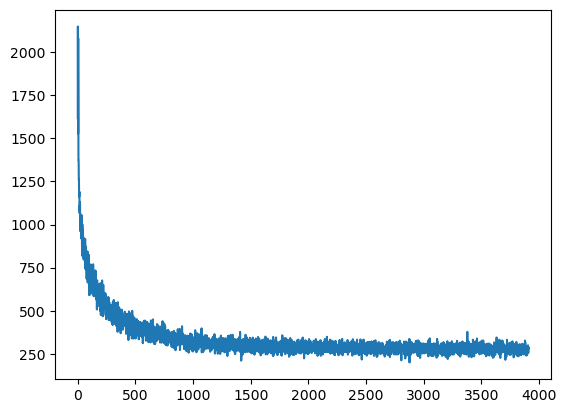

In [25]:
with open(log_file, "r") as f:
    all_loss = [float(line) for line in f]
num_rec = len(all_loss) * 10 // num_epochs
plt.plot(all_loss[:num_rec])

## 使用训练好的模型进行图像生成

现在让我们使用上述训练好的模型 (RefineNet) 来创建图像。

如上所述，通过对 $t=1, \ldots ,T$ 和 $i=1, \ldots ,L$（即嵌套循环）应用以下方程来生成图像。

$$\displaystyle \mathbf{x}_t = \mathbf{x}_{t-1} + \frac{\alpha_i}{2} \mathbf{s}_{\theta}(\mathbf{x}_{t-1}, i) + \sqrt{\alpha_i}\mathbf{z}_t $$

其中 $\alpha_i = \epsilon \cdot \sigma_i^2 / \sigma_L^2$（带有缩放参数 $\epsilon$ 的步长）并且 $\mathbf{z}_t \sim \mathcal{N}(\mathbf{0},\mathbf{I})$。

正如您可以在这段源代码中看到的，我们使用**均匀噪声**作为初始样本。

我注意到 $\sigma_i$（标准差）在迭代中随着 $i$ 的增加而减小。

100%|██████████| 10/10 [02:03<00:00, 12.38s/it]


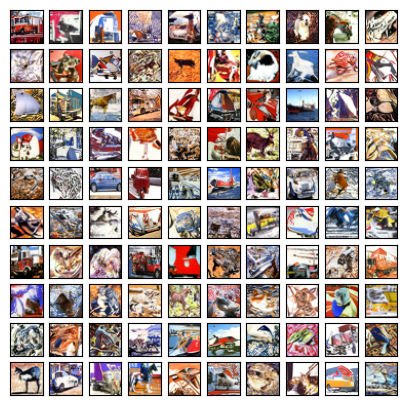

In [27]:
import tqdm

T = 100

def run_inference(unet, x_0, sigmas, T):
    x = x_0
    b = x_0.size(dim=0)
    with torch.no_grad():
        # (showing progress, because it needs a lot of time.)
        # for idx, sigma in enumerate(sigmas):
        for idx, sigma in tqdm.tqdm(enumerate(sigmas), total=len(sigmas)):
            i = torch.ones(b, dtype=int).to(device) * idx
            eps = 2e-5
            alpha = (sigma / sigmas[-1])**2*eps
            for t in range(T):
                model_out = unet(x, i)
                z = torch.randn_like(x).to(device)
                x = x + model_out*alpha*0.5 + z*torch.sqrt(alpha)
    # clip
    x = torch.clamp(x, min=0.0, max=1.0)
    return x

num_row = 10
num_col = 10

# initialize x_0
x_0 = torch.rand(num_row*num_col, 3, 32, 32).to(device)
# generate images
x = run_inference(unet, x_0, sigmas, T)
# draw
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
for i in range(num_row*num_col):
    image = x[i].cpu().numpy()
    channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
    row = i//num_col
    col = i%num_col
    ax = axes[row, col]
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(channel_last)